In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/private-dataset/players.csv


In [2]:
df=pd.read_csv('/kaggle/input/private-dataset/players.csv')

# checking null values

In [3]:
df.isnull().mean()*100

player               0.000000
team                 0.000000
team_country         0.000000
position             0.000000
age                  0.000000
                      ...    
gk_pens_att         95.974235
gk_pens_allowed     95.974235
gk_pens_saved       95.974235
gk_pens_missed      95.974235
gk_pens_save_pct    99.516908
Length: 72, dtype: float64

In [4]:
df.shape

(1242, 72)

# removing 50% > null data columns

In [5]:
df = df.loc[:,df.isnull().mean()<=0.5]

In [6]:
df.shape

(1242, 46)

In [7]:
df['age']=df['age'].str[:2].astype(int)
df['age'].head()

0    27
1    23
2    26
3    24
4    34
Name: age, dtype: int64

# remove useless columns

In [8]:
df=df.drop(columns=['player','team','team_country','club','birth_year'])
df.shape

(1242, 41)

# convert cat -> num values

In [9]:
df['position'] = df['position'].astype(str).str.split(',').str[0]
df['position'] = df['position'].astype('category').cat.codes
df['position'].value_counts()

position
0    423
3    392
1    282
2    145
Name: count, dtype: int64

# handle missing values

In [10]:
df=df.fillna(df.mean(numeric_only=True))
df.isnull().sum().sum()

np.int64(0)

In [11]:
y = df['goals']

leaky_cols = ['goals', 'goals_per90', 'goals_assists', 'goals_pens',
              'goals_assists_per90', 'goals_pens_per90', 'goals_assists_pens_per90',
              'goals_per_shot', 'goals_per_shot_on_target']

x = df.drop(columns=[c for c in leaky_cols if c in df.columns])
print(x.shape, y.shape)

(1242, 34) (1242,)


# Evaluation

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# scaling values 

In [13]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

# model selection

# model 1

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

print("R2 :", round(r2_score(y_test, y_pred_lr), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred_lr), 4))
print("MSE:", round(mean_squared_error(y_test, y_pred_lr), 4))

R2 : 0.6096
MAE: 0.1085
MSE: 0.0447


# model 2

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print("R2 :", round(r2_score(y_test, y_pred_rf), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred_rf), 4))
print("MSE:", round(mean_squared_error(y_test, y_pred_rf), 4))

R2 : 0.6819
MAE: 0.0628
MSE: 0.0364


# visualize result

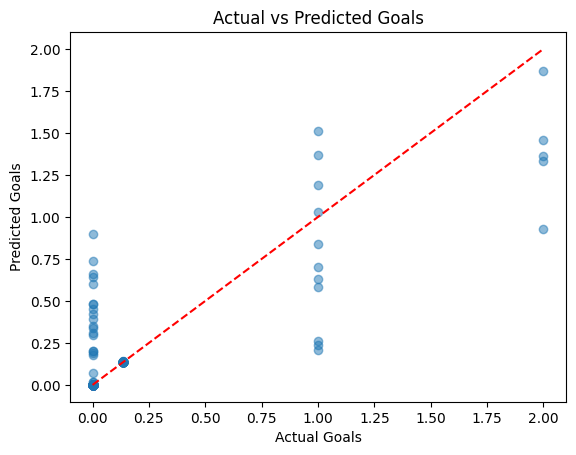

In [16]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Goals')
plt.ylabel('Predicted Goals')
plt.title('Actual vs Predicted Goals')
plt.show()